# ISOMIGA AD coloc protective LINCS matching

This notebook summarizes preliminary drug-prioritization data for ISOMIGA microglia eQTL colocalizations with AD GWAS. The protective expression direction is inferred from the signs of the AD GWAS SNP beta and eQTL SNP beta: same sign means increased expression tracks AD risk, opposite sign means increased expression tracks protection.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from plotnine import *

DATA = Path("../data/processed")
FIG = Path("../results/figures")
FIG.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 80)

## Protective expression targets

In [2]:
targets = pd.read_csv(DATA / "protective_expression_targets.tsv", sep="\t")
gene_targets = pd.read_csv(DATA / "protective_expression_gene_summary.tsv", sep="\t")
coverage_path = DATA / "lincs_target_gene_coverage.tsv"
coverage = pd.read_csv(coverage_path, sep="\t") if coverage_path.exists() else None

print(f"High-H4 coloc target rows: {len(targets):,}")
print(f"Unique genes: {gene_targets['gene_name'].nunique():,}")
print(gene_targets['protective_direction_label'].value_counts(dropna=False))
gene_targets.head(20)

High-H4 coloc target rows: 52
Unique genes: 27
protective_direction_label
decrease    20
increase     7
Name: count, dtype: int64


,gene_name,n_coloc,max_h4,mean_h4,protective_score,total_weight,protective_expression_direction,protective_direction_label,abs_protective_score
0,EPHA1-AS1,2,1.000000,1.000000,-27.557003,27.557003,-1.0,decrease,27.557003
1,ZYX,2,0.999999,0.999997,-13.152031,13.152031,-1.0,decrease,13.152031
2,BIN1,4,0.999914,0.998207,-21.886540,21.886540,-1.0,decrease,21.886540
3,TAS2R60,1,0.999892,0.999892,-4.507663,4.507663,-1.0,decrease,4.507663
4,RP11-960L18.1,2,0.999122,0.999050,-15.334494,15.334494,-1.0,decrease,15.334494
5,CYP27C1,4,0.998687,0.998334,-20.727582,20.727582,-1.0,decrease,20.727582
6,RASGEF1C,2,0.997078,0.996848,-14.039983,14.039983,-1.0,decrease,14.039983
7,novelGene_813,1,0.997069,0.997069,-7.824133,7.824133,-1.0,decrease,7.824133
8,AC093673.5,2,0.996383,0.973869,-7.673144,7.673144,-1.0,decrease,7.673144
9,PLCG2_RP11-960L18.1_RN7SKP176,1,0.993119,0.993119,4.745129,4.745129,1.0,increase,4.745129


/gpfs/commons/home/daknowles/projects/lincs_microglial/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 5 x 3 in image.
/gpfs/commons/home/daknowles/projects/lincs_microglial/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../results/figures/target_direction_counts.png


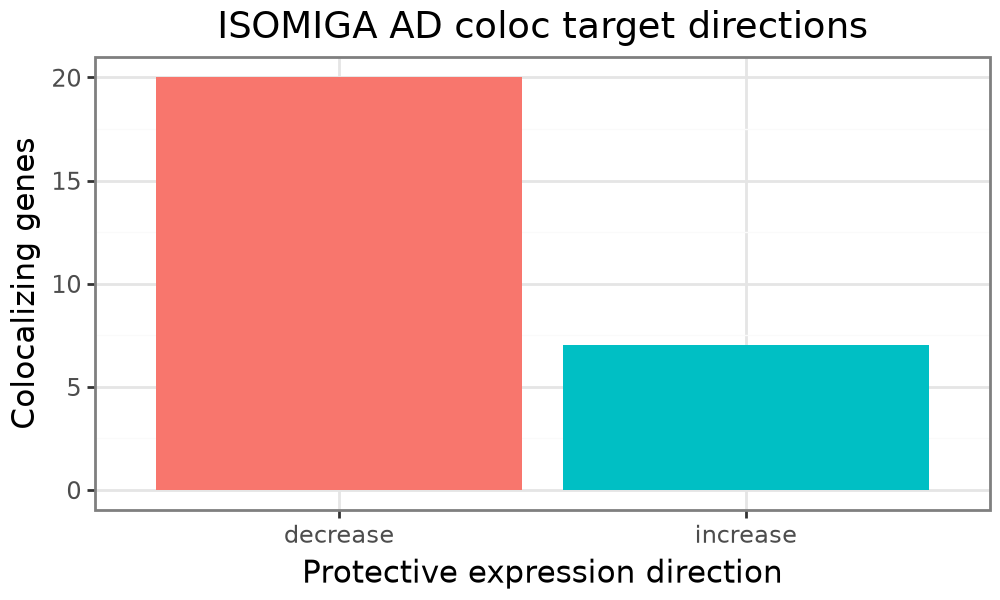

In [3]:
p = (
    ggplot(gene_targets, aes("protective_direction_label", fill="protective_direction_label"))
    + geom_bar(show_legend=False)
    + labs(x="Protective expression direction", y="Colocalizing genes", title="ISOMIGA AD coloc target directions")
    + theme_bw()
    + theme(figure_size=(5, 3))
)
p.save(FIG / "target_direction_counts.png", dpi=300)
p

/gpfs/commons/home/daknowles/projects/lincs_microglial/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 7 x 6 in image.
/gpfs/commons/home/daknowles/projects/lincs_microglial/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../results/figures/top_coloc_targets.png


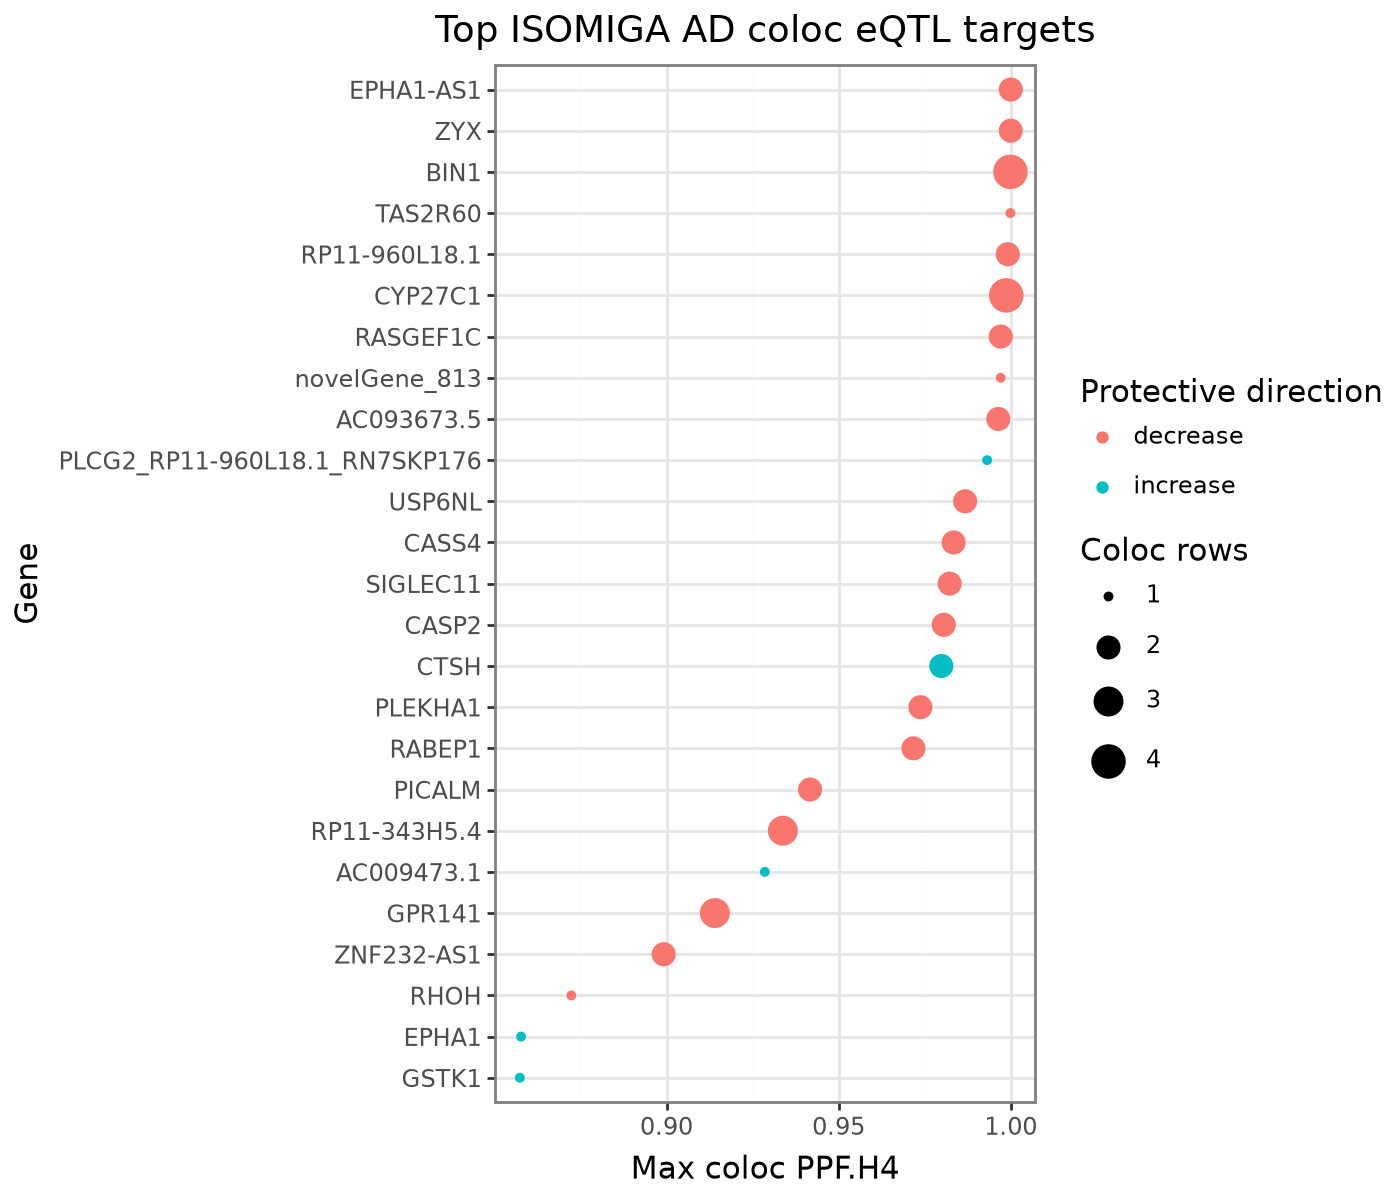

In [4]:
top_targets = (
    gene_targets.sort_values(["max_h4", "abs_protective_score"], ascending=False)
    .head(25)
    .assign(gene_name=lambda x: pd.Categorical(x["gene_name"], categories=x["gene_name"][::-1], ordered=True))
)
p = (
    ggplot(top_targets, aes("max_h4", "gene_name", color="protective_direction_label", size="n_coloc"))
    + geom_point()
    + labs(x="Max coloc PPF.H4", y="Gene", color="Protective direction", size="Coloc rows", title="Top ISOMIGA AD coloc eQTL targets")
    + theme_bw()
    + theme(figure_size=(7, 6))
)
p.save(FIG / "top_coloc_targets.png", dpi=300)
p

## LINCS target coverage

In [5]:
if coverage is None:
    print("Run scripts/extract_lincs_thp1_targets.py to produce LINCS target coverage.")
else:
    display(coverage['in_lincs'].value_counts(dropna=False))
    display(coverage.sort_values(['in_lincs', 'gene_name'], ascending=[True, True]).head(30))

in_lincs
False    14
True     13
Name: count, dtype: int64

,gene_name,gene_id,in_lincs
0,AC009473.1,NaN,False
1,AC093673.5,NaN,False
6,CYP27C1,NaN,False
8,EPHA1-AS1,NaN,False
9,GPR141,NaN,False
12,PLCG2_RP11-960L18.1_RN7SKP176,NaN,False
16,RASGEF1C,NaN,False
18,RP11-343H5.4,NaN,False
19,RP11-661A12.8,NaN,False
20,RP11-960L18.1,NaN,False


## THP1 drug scores

In [6]:
drug_scores_path = DATA / "lincs_thp1_protective_drug_scores.tsv"
drug_gene_path = DATA / "lincs_thp1_protective_drug_gene_scores.tsv"
if drug_scores_path.exists() and drug_gene_path.exists():
    drug_scores = pd.read_csv(drug_scores_path, sep="\t")
    drug_gene = pd.read_csv(drug_gene_path, sep="\t")
    display(drug_scores.head(25))
else:
    drug_scores = None
    drug_gene = None
    print("Run scripts/run_pipeline.sh through LINCS extraction/scoring to populate drug score files.")

,pert_id,pert_iname,n_target_genes,n_protective_genes,n_strong_protective_genes,n_opposing_genes,mean_protective_push_z,median_protective_push_z,summed_weighted_push,total_weight,min_n_signatures,total_gene_signatures,weighted_mean_protective_push_z,fraction_genes_protective
0,BRD-K04623885,BIBR-1532,13,10,6,3,0.710964,0.457883,75.386413,122.698097,1,13,0.614406,0.769231
1,BRD-K41895714,AS-605240,13,6,5,7,-0.140969,-0.156459,26.495128,122.698097,1,13,0.215938,0.461538
2,BRD-K67566344,KU-0063794,13,6,5,7,-0.446592,-1.327550,-26.922158,122.698097,1,13,-0.219418,0.461538
3,BRD-A77216878,manumycin-a,13,6,5,7,-0.329792,-0.833900,-58.522040,122.698097,1,13,-0.476960,0.461538
4,BRD-K60623809,SU-11652,13,6,5,7,-1.039500,-1.088500,-68.537584,122.698097,1,13,-0.558587,0.461538
5,BRD-K09635314,m-3M3FBS,13,5,5,8,-0.962198,-1.682019,-174.899500,122.698097,1,13,-1.425446,0.384615
6,BRD-A35588707,teniposide,13,7,4,6,0.242831,0.095150,34.929376,122.698097,1,13,0.284677,0.538462
7,BRD-A13122391,triptolide,13,9,4,4,0.372055,0.326528,15.252102,122.698097,1,13,0.124306,0.692308
8,BRD-K15409150,penfluridol,13,8,4,5,0.265885,0.581300,12.061832,122.698097,1,13,0.098305,0.615385
9,BRD-K36927236,glibenclamide,13,6,4,7,0.165823,-0.097600,-3.791037,122.698097,1,13,-0.030897,0.461538


In [7]:
if drug_scores is not None:
    top_drugs = (
        drug_scores.head(20)
        .assign(pert_iname=lambda x: pd.Categorical(x["pert_iname"], categories=x["pert_iname"][::-1], ordered=True))
    )
    p = (
        ggplot(top_drugs, aes("weighted_mean_protective_push_z", "pert_iname"))
        + geom_col(fill="#3b6ea8")
        + geom_point(aes(size="n_protective_genes"), color="#111111")
        + labs(x="Weighted mean protective push z", y="Compound", size="Protective genes", title="Top THP1 LINCS compounds by protective expression push")
        + theme_bw()
        + theme(figure_size=(7, 6))
    )
    p.save(FIG / "top_lincs_protective_drugs.png", dpi=300)
    p

/gpfs/commons/home/daknowles/projects/lincs_microglial/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 7 x 6 in image.
/gpfs/commons/home/daknowles/projects/lincs_microglial/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../results/figures/top_lincs_protective_drugs.png


In [8]:
if drug_gene is not None and drug_scores is not None:
    selected = drug_scores.head(12)[["pert_id", "pert_iname"]]
    heat = drug_gene.merge(selected, on=["pert_id", "pert_iname"])
    gene_order = (
        heat.groupby("gene_name")["max_h4"].max().sort_values(ascending=False).index.tolist()
    )
    heat["gene_name"] = pd.Categorical(heat["gene_name"], categories=gene_order[::-1], ordered=True)
    heat["pert_iname"] = pd.Categorical(heat["pert_iname"], categories=selected["pert_iname"][::-1], ordered=True)
    p = (
        ggplot(heat, aes("pert_iname", "gene_name", fill="protective_push_z"))
        + geom_tile(color="white")
        + scale_fill_gradient2(low="#9c2f2f", mid="#f7f7f7", high="#2f7d4f", midpoint=0)
        + labs(x="Compound", y="Target gene", fill="Protective push z", title="Per-gene protective push for top compounds")
        + theme_bw()
        + theme(figure_size=(8, max(4, 0.25 * len(gene_order))), axis_text_x=element_text(rotation=45, ha="right"))
    )
    p.save(FIG / "top_drug_gene_protective_push_heatmap.png", dpi=300)
    p

/gpfs/commons/home/daknowles/projects/lincs_microglial/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8 x 4 in image.
/gpfs/commons/home/daknowles/projects/lincs_microglial/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../results/figures/top_drug_gene_protective_push_heatmap.png


## Export prelim tables

In [9]:
if drug_scores is not None:
    cols = ["pert_iname", "n_target_genes", "n_protective_genes", "n_strong_protective_genes", "weighted_mean_protective_push_z", "fraction_genes_protective", "min_n_signatures"]
    prelim = drug_scores.loc[:, cols].head(50)
    prelim.to_csv(DATA / "prelim_top_lincs_thp1_protective_drugs.tsv", sep="\t", index=False)
    display(prelim.head(20))

,pert_iname,n_target_genes,n_protective_genes,n_strong_protective_genes,weighted_mean_protective_push_z,fraction_genes_protective,min_n_signatures
0,BIBR-1532,13,10,6,0.614406,0.769231,1
1,AS-605240,13,6,5,0.215938,0.461538,1
2,KU-0063794,13,6,5,-0.219418,0.461538,1
3,manumycin-a,13,6,5,-0.476960,0.461538,1
4,SU-11652,13,6,5,-0.558587,0.461538,1
5,m-3M3FBS,13,5,5,-1.425446,0.384615,1
6,teniposide,13,7,4,0.284677,0.538462,1
7,triptolide,13,9,4,0.124306,0.692308,1
8,penfluridol,13,8,4,0.098305,0.615385,1
9,glibenclamide,13,6,4,-0.030897,0.461538,1
